In [3]:
import numpy as np  
import random  
import matplotlib.pyplot as plt  
from PIL import Image  
import os  

In [6]:
# Quadtree:
class Quadtree:
    def __init__(self, x_min, x_max, y_min, y_max, max_points=4, depth=0):
        self.x_min, self.x_max = x_min, x_max  # x ašies riba
        self.y_min, self.y_max = y_min, y_max  # y ašies riba
        self.max_points = max_points  # Maksimalus dalelių skaičius viename node
        self.depth = depth  # Nusako quadtree gylį (nusako nodų skaičių)
        self.points = []  # taškai viename node
        self.children = []  # child nodai

    def insert(self, point, index):
        # Patikrina ar taškas tam tikro nodo ribose
        if not (self.x_min < point[0] < self.x_max and self.y_min < point[1] < self.y_max):
            return False  
        
        # Jei yra vietos ir nėra child nodo jis sukūria tašką laisvoje vietoje
        if len(self.points) < self.max_points and not self.children:
            self.points.append((point, index))  
            return True
        
        #Jei nėra child nodo jis padalija nodą į 4 child nodus
        if not self.children:
            self.subdivide()
        
        # įkelia tašką į vieną iš child nodų
        for child in self.children:
            if child.insert(point, index):
                return True
        return False
    
    def subdivide(self):
        # Padalina nodą į 4 child nodus ir suranda jų vidurio tašką
        mid_x = (self.x_min + self.x_max) / 2
        mid_y = (self.y_min + self.y_max) / 2
        self.children = [
            Quadtree(self.x_min, mid_x, self.y_min, mid_y, self.max_points, self.depth + 1),
            Quadtree(mid_x, self.x_max, self.y_min, mid_y, self.max_points, self.depth + 1),
            Quadtree(self.x_min, mid_x, mid_y, self.y_max, self.max_points, self.depth + 1),
            Quadtree(mid_x, self.x_max, mid_y, self.y_max, self.max_points, self.depth + 1),
        ]  # Sukuria 4 child nodus
        for point, index in self.points:  # Perkelia taškus iš parent nodo į child nodą
            for child in self.children:
                if child.insert(point, index):
                    break
        self.points = []  # Ištrina taškus iš parent nodo.
    
    def query_range(self, x, y, radius): #query_range ieško tam tikrų taškų Quadtree erdvėje
        results = []  
        # Patikrina ar tai įeina į Quadtree ribas 
        if x + radius < self.x_min or x - radius > self.x_max or y + radius < self.y_min or y - radius > self.y_max:
            return results  
        
        # Patikrina taškus mazge ar jie įeina į spindulį
        for point, index in self.points:
            if np.linalg.norm(np.array(point) - np.array([x, y])) <= radius:
                results.append(index)
        
       
        if self.children:
            for child in self.children:
                results.extend(child.query_range(x, y, radius))  # Čia kaip suprantu Quadtree tikrina kurie "children" turi tam tikram spinduly dalelių kurie ne tuos atmeta.
        return results

In [7]:
# Klasė kuri sukūria daleles ir parenka jiems lokalizuotas būsens, energiją ir poziciją.
class LocalizedStates:
    def __init__(self, N, box_size):
        self.N = N  # Lokalizuotų būsenų skaičius (dalelių skaičius)
        self.box_size = box_size  # Dydis tos erdvės kur yra dalelės
        
        # Parenka tiek pozicijų kiek yra dalelių
        self.positions = np.random.rand(N, 2) * box_size  # Parenka pozicijas
        # Sukūria energijas nuo -0.1 iki 0
        self.energies = np.random.uniform(-0.1, 0.0, size=N)
        
        # Sukūria Quadtree pozicijas
        self.tree = Quadtree(0, box_size, 0, box_size)
        for i in range(N):
            self.tree.insert(self.positions[i], i)  # Įrašo kiekvieną dalelę į Quadtree
    
    def update_plot(self, ax, colorbar=False):  #plotinimas
        ax.clear()  # Clear the axes
        scatter = ax.scatter(self.positions[:, 0], self.positions[:, 1], c=self.energies, cmap='coolwarm', vmin=-0.1, vmax=0.0)  # Plot positions with energies
        ax.set_xlabel("X Position (nm)")  
        ax.set_ylabel("Y Position (nm)")  
        ax.set_title("Localized States in AlGaAs")  
        
        if colorbar:   #Colorbaras
            cbar = ax.figure.colorbar(scatter, ax=ax, label="Energy (eV)")
        
        return scatter

In [12]:
def miller_abrahams_rate(E_i, E_j, r_ij, a, nu_0, kT): #Miller abramso formulė kuri nusako galimybę(šansą) dalalei peršokti
    if E_j > E_i:
        return nu_0 * np.exp(-2 * r_ij / a) * np.exp(-(E_j - E_i) / kT)  
    else:
        return nu_0 * np.exp(-2 * r_ij / a)  

In [14]:
# KMC klasė
class KMC_Simulator:
    def __init__(self, states, a=5.0, nu_0=1e13, kT=0.025):
        self.states = states  # Lokalizacijos būsenos
        self.a = a  # Lokalizacijos ilgis (nm)
        self.nu_0 = nu_0  # Dažnis (Hz)
        self.kT = kT  # Energija (eV)
        self.time = 0  # Simuliacijos laikas
    
    def run_step(self):
        idx = random.randint(0, self.states.N - 1)  # Paima bet kurią lokalizuotą būsena
        pos_i = self.states.positions[idx].copy()
        E_i = self.states.energies[idx]  #Išsaugo jos poziciją ir energiją
        print("Index:", idx)
        print("Current position:", pos_i)
        print("Current energy:", E_i)

        
        #Pagal 10nm atstumą ieško būsenų į kurias gali peršokti tame Quadtree
        neighbors_idx = self.states.tree.query_range(pos_i[0], pos_i[1], 10)
        if len(neighbors_idx) < 2:  #Jei nėra galimų būsenų tada praleidžia
            return
        


        rates = []  # Čia išsaugo šokinėjimus, kad paskui gauti jų dažnį
   
        for j in neighbors_idx: # Pereina per kaimynines būsenas kad patikrintų ar gali peršokti
            if j == idx:
                continue  

            r_ij = np.linalg.norm(self.states.positions[j] - pos_i) # Suskaičiuoja atstumą tarp pozicijų
            if r_ij < 1e-6:
                continue  

            rate = miller_abrahams_rate(E_i, self.states.energies[j], r_ij, self.a, self.nu_0, self.kT) # Pagal Millerio-Abramso formulę yra suskaičiuojamas Millerio-Abramso dažnis

            print("Neighbor index:", j)
            print("Distance to neighbor:", r_ij)
            print("Neighbor energy:", self.states.energies[j])
            print("Calculated rate:", rate)
            rates.append((j, rate))

        
        if not rates:  # Jei nėra jokių šokinėjimų tada tiesiog praleidžia tai
            return
        
        total_rate = sum(r for _, r in rates)  # suskaičiuojamas šokinėjimo dažnis
        if total_rate == 0:
            return
        
        r_select = random.uniform(0, total_rate)  # Tam tikra vertė kuri nusako šokinėjimo dažnį
        cumulative = 0
        for j, rate in rates:
            cumulative += rate
            if cumulative >= r_select:  # Kai cumulative tampa didesnis už tam tikrą vertę tada dalelė peršoka į kitą būseną
                print("Jumping to state:", j)
                self.states.positions[idx] = np.random.rand(2) * self.states.box_size  # Monte-Carlo parenka nauja poziciją
                self.states.energies[idx] = self.states.energies[j]  # Po persikelimo gauna tą pačią energiją kaip ir dalelė kuri buvo čia prieš tai
                break
        
        dt = -np.log(random.random()) / total_rate  # delta t suskaičiojamas pagal total rate
        self.time += dt
        print("Delta t:", dt)
        print("Total time:", self.time)
    
    def run_simulation(self, steps=100, save_path="exciton_simulation.gif"): #Simuliacijos funkcija
        fig, ax = plt.subplots(figsize=(6, 6))  
        
        frames = []  # Plotų(framų) listas
        
        self.states.update_plot(ax, colorbar=True)  #Pradinis plotas nusako koksai bus colorbar, kad nesikeistų per daug
        
        for _ in range(steps):  # Simuliacija veikia tiek kiek jai yra duota žingsnių
            self.run_step()  #KMC Simuliacija veikia
            scatter = self.states.update_plot(ax, colorbar=False)  #Atnaujina plotą
            
            frame_path = f"frame_{_}.png"  # Išsaugo kiekvieną Frame'ą gifo kūrimui
            plt.savefig(frame_path)
            frames.append(frame_path)
        
        self.create_gif(frames, save_path)  #Sukuria gifą iš framų
        
        for frame in frames:  
            os.remove(frame)
    
    def create_gif(self, frames, save_path): #Gifo kurimo funkcija
        images = []  
        for frame in frames:
            img = Image.open(frame)  
            images.append(img)
        
        images[0].save(save_path, save_all=True, append_images=images[1:], duration=100, loop=0)  
        print(f"GIF saved as {save_path}")  


Index: 3
Current position: [72.17776772 63.89751457]
Current energy: -0.09181843921360332
Index: 2
Current position: [79.79977747 29.05783073]
Current energy: -0.08844625556058325
Index: 4
Current position: [ 6.63833194 24.03358808]
Current energy: -0.04687417885891762
Index: 2
Current position: [79.79977747 29.05783073]
Current energy: -0.08844625556058325
Index: 3
Current position: [72.17776772 63.89751457]
Current energy: -0.09181843921360332
Index: 0
Current position: [25.27598403  9.99689211]
Current energy: -0.07254937054343295
Index: 0
Current position: [25.27598403  9.99689211]
Current energy: -0.07254937054343295
Index: 0
Current position: [25.27598403  9.99689211]
Current energy: -0.07254937054343295
Index: 1
Current position: [91.34144152 56.41256314]
Current energy: -0.02073800437887656
Index: 3
Current position: [72.17776772 63.89751457]
Current energy: -0.09181843921360332
GIF saved as exciton_simulation.gif


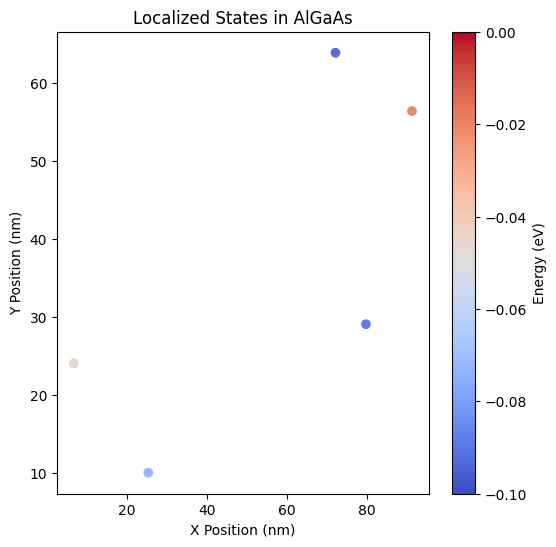

In [15]:
states = LocalizedStates(N=5, box_size=100) #Kiek dalelių ir kiek lokalizuotų būsenų skaičius (100x100)
sim = KMC_Simulator(states, a=5.0, nu_0=1e13, kT=0.00001) #KMC simulatorius simuliuoja jų šokinėjimą pagal nu, kT ir a parametrus
sim.run_simulation(steps=10, save_path="exciton_simulation.gif") #sukuria 100 framu iš kurių padaro simulacijos gifą